In [2]:
%load_ext autoreload
%autoreload 2

# Enable packages in project notebook (not required for .py scripts)
import sys
import os

# Add the project root or parent folder to sys.path
sys.path.append(os.path.abspath("../../")) 


import yaml
import pickle
from tqdm import tqdm

import numpy as np
import jax.numpy as jnp
import pandas as pd

import seaborn as sns
palette = sns.color_palette("Paired", 6)

import jax
import optax
import torch
import torch.utils.data as data

import counterfactual_alignment as cfa
from counterfactual_alignment import custom_datasets, custom_models, loss_functions, knowledge_functions
from counterfactual_alignment import utilities as ut

from counterfactual_alignment.pipeline import Pipeline


import numpy as np
import jax.numpy as jnp
from tqdm.auto import tqdm
import jax

# FAT Forensics Counterfactual Explainer
import fatf.transparency.predictions.counterfactuals as fatf_cf
from counterfactual_alignment.utilities import get_rand_vec, get_unit_vec


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
"""
Load DATASET
"""
# Get the directory where THIS script is located
script_dir = os.path.dirname(os.path.abspath(''))

# Build path to "data" folder inside that directory
data_folder = os.path.join(script_dir, 'data')

data_name = 'integer_len64'


with open(os.path.join(data_folder,data_name)+'.pkl', 'rb') as file:
    datasets = pickle.load(file)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jonathanerskine/University of Bristol/gradient_supervision/counterfactual-gradient-alignment/Projects/data/integer_len64.pkl'

In [2]:
"""
Gen Datasets
"""

"""
Initialise Parameters
"""

config_file = "config.yaml" #assuming local yaml file
with open(config_file,'r') as file:
    config = yaml.unsafe_load(file)

seed = seed=config['hyperparams']['seed']
key = jax.random.PRNGKey(seed)
noise_key,sample_key,model_key = jax.random.split(key,3)

def optimum_classifier(Z):
        """
        Inputs  | z:      x,y coordinates of data to be classified.
        Outputs | probs:  array of probabilities for each class for input data.
        """
        return np.array([int(z[0]>=0) for z in Z])


size = config['data_params']['train_size'] + config['data_params']['validation_size']

X_dims = 2
X = np.array([(x,x**2) for x in np.linspace(-5,5,size)]) + jax.random.normal(noise_key,(size,X_dims))*0.5 # multiply by scaling factor

Y = np.zeros_like(X[:,0])
Y[int(size/2 + size%2):] = 1

y_preds = optimum_classifier(X)

sample_indices = np.empty(0)
# sample training set
for i,_ in enumerate(list(set(Y))):
      sample_indices = np.concatenate((sample_indices,jax.random.randint(sample_key,tuple([int(config['data_params']['train_size']/2)]),np.ceil(i*size/2),np.floor((i+1)*size/2))))

# sample_indices = jax.random.permutation(sample_key,size)[:config['data_params']['train_size']] 


X_train_CE = np.array([X[int(i)] for i in sample_indices])
Y_train_CE = np.array([Y[int(i)] for i in sample_indices])


X_test = np.array([X[i] for i in range(size) if i not in sample_indices])
Y_test = np.array([Y[i] for i in range(size) if i not in sample_indices])

full_df = pd.DataFrame({'x_0':X[:,0],
                         'x_1':X[:,1],
                         'Class':Y})

train_df = pd.DataFrame({'x_0':X_train_CE[:,0],
                         'x_1':X_train_CE[:,1],
                         'Class':Y_train_CE})

test_df = pd.DataFrame({'x_0':X_test[:,0],
                         'x_1':X_test[:,1],
                         'Class':Y_test})


datasets = {'train' :data.TensorDataset(torch.tensor(X_train_CE),torch.tensor(Y_train_CE),torch.tensor(np.zeros_like(X_train_CE))),
            'test'  :data.TensorDataset(torch.tensor(X_test),torch.tensor(Y_test),torch.tensor(np.zeros_like(X_test)))}


In [6]:

def counterfactual_feasible_vector_paths(X,Y, classifier, n_samples=3):
    print(f"Generating {n_samples} counterfactual samples per observation ...")
  # Lets generate the nearest point where the classification boundary changes
    # For now, generate the nearest n_vec counterfactuals, and keep the rest the same?
    # classes = np.unique(Y)
    classes = list(set(Y))

    cf_explainer = fatf_cf.CounterfactualExplainer(predictive_function = classifier,
                                                      dataset = X,
                                                      numerical_indices=[0,1],
                                                      default_numerical_step_size=0.1,
                                                      max_counterfactual_length=1)
    
    origins = np.zeros((len(X),n_samples, len(X[0])))
    
    directions = distances =  np.zeros((len(X), len(X[0])))
    
    for i, x in tqdm(enumerate(X)):
      
      counterfactual_class = int(next(c for c in classes if c != Y[i]))
      
      cf, distance, label = cf_explainer.explain_instance(np.array(x),
                                                                counterfactual_class,
                                                                normalise_distance=False)
      
      if np.shape(cf)[0] > 1: # horrible fix for unknown behaviour where 2 cfs are generated instead of one - only seems to occur when x == cf
          cf = [list(cf[0])]

      if np.allclose(np.array(cf[0]),np.array(x)):
         directions[i] = np.array([np.nan,np.nan])
         
      else:  
        directions[i],_ = get_unit_vec(x,cf[0])
      
      vector = cf[0] - x
      # Get vector magnitude in each axis
      delta_x, delta_y = vector[0], vector[1]
      boundary = 0.1
      d_values = np.linspace(0.0 + boundary, 1 - boundary, n_samples)
      # print('vec: ',vector,' | d: ',d_values)
      # for k, d in enumerate(d_values):
      #     # Nonlinear interpolation along curve: scale by d²
      #     origins[i, k, :] = x + (d ** 2) * vector

      for k, t in enumerate(d_values):
            curved_point = np.array([
                x[0] + t * delta_x,
                x[1] + (t ** 2) * delta_y
            ])
            origins[i, k, :] = curved_point



    
    return {'origin'    :origins,
            'vector'    :directions}

In [91]:
def counterfactual_feasible_vector_paths(X, Y, classifier, n_samples=3):
    print(f"Generating {n_samples} counterfactual samples per observation ...")
    classes = list(set(Y))

    cf_explainer = fatf_cf.CounterfactualExplainer(
        predictive_function=classifier,
        dataset=X,
        numerical_indices=[0, 1],
        default_numerical_step_size=0.1,
        max_counterfactual_length=1
    )

    origins = np.zeros((len(X), n_samples, len(X[0])))
    directions = distances = np.zeros((len(X), len(X[0])))

    for i, x in tqdm(enumerate(X)):
        counterfactual_class = int(next(c for c in classes if c != Y[i]))

        cf, distance, label = cf_explainer.explain_instance(
            np.array(x),
            counterfactual_class,
            normalise_distance=False
        )

        if np.shape(cf)[0] > 1:
            cf = [list(cf[0])]

        cf_point = np.array(cf[0])
        x = np.array(x)

        if np.allclose(cf_point, x):
            directions[i] = np.array([np.nan, np.nan])
            continue

        # Interpolate along x and compute y = x^2 to follow true distribution
        x_start, x_end = sorted([x[0], cf_point[0]])
        boundary = abs(x_end-x_start) * 0.05
        
        x_vals = np.linspace(x_start+boundary, x_end-boundary, n_samples)
        
        
        for k, x_val in enumerate(x_vals):
            y_val = x_val ** 2
            origins[i, k, :] = [x_val, y_val]

        # Vector from original x to cf (used for directional derivatives later)
        directions[i], _ = get_unit_vec(x, cf_point)

    return {
        'origin': origins,
        'vector': directions
    }


In [92]:
n_samples = config['data_params']['n_vec']


knowledge = counterfactual_feasible_vector_paths(X_train_CE,Y_train_CE,classifier=optimum_classifier,n_samples=n_samples)

X_train_D = knowledge['origin'].reshape(int(n_samples*config['data_params']['train_size']),X_dims)
Y_train_D = np.array([[y]*n_samples for y in Y_train_CE]).reshape(int(n_samples*config['data_params']['train_size']))

K_df = pd.DataFrame({'x_0':X_train_D[:,0],
                      'x_1':X_train_D[:,1],
                      'Class':Y_train_D})

# 

k_dim = np.shape(knowledge['origin'])

K_train_D = np.vstack([
    knowledge['vector'][i] for i in range(k_dim[0]) for _ in range(k_dim[1])
])


batch = {'train':{
            'original':{
                'X':X_train_CE,
                'Y':Y_train_CE
            },
            'additional':{
                'X':X_train_D,
                'Y':Y_train_D,
                'K':K_train_D
            }},
         'test':{
             'X':X_test,
             'Y':Y_test
         }}



Generating 3 counterfactual samples per observation ...


2it [00:00, 1123.57it/s]


In [93]:
knowledge

{'origin': array([[[-4.02024809e+00,  1.61623947e+01],
         [-2.08524809e+00,  4.34825959e+00],
         [-1.50248089e-01,  2.25744882e-02]],
 
        [[ 4.07905006e-02,  1.66386494e-03],
         [ 7.25137806e-01,  5.25824838e-01],
         [ 1.40948511e+00,  1.98664828e+00]]]),
 'vector': array([[ 1.,  0.],
        [-1.,  0.]])}

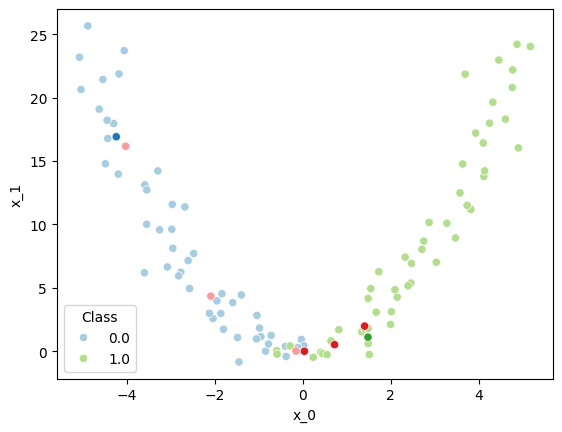

In [94]:

if config['visualisation']['visualise']:
#     fulldata_scatter = sns.scatterplot(data=full_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]],alpha=0.5,s=5,legend=False)
    test_scatter = sns.scatterplot(data=test_df,x='x_0',y='x_1',hue='Class',palette=[palette[0],palette[2]])
    K_scatter = sns.scatterplot(data=K_df,x='x_0',y='x_1',hue='Class',palette=[palette[4],palette[5]],legend=False)
    train_scatter = sns.scatterplot(data=train_df,x='x_0',y='x_1',hue='Class',palette=[palette[1],palette[3]],legend=False)
    